In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
BASE_PATH = Path(r"C:\Users\nshivane\anemia-project\data\raw")

# AneRBC - Original_Images subfolders (AneRBC-II: 12,000 images)
ANERBC_HEALTHY = BASE_PATH / "AneRBC" / "AneRBC_dataset" / "AneRBC-II" / "Healthy_individuals" / "Original_Images"
ANERBC_ANEMIC = BASE_PATH / "AneRBC" / "AneRBC_dataset" / "AneRBC-II" / "Anemic_individuals" / "Original_Images"

# Chula-RBC-12 - Dataset folder (706 images)
CHULA_PATH = BASE_PATH / "Chula-RBC-12" / "Dataset"

# RBC (Zenodo combined)
RBC_PATH = BASE_PATH / "RBC"

# Create folders if they don't exist
for p in [BASE_PATH, ANERBC_HEALTHY, ANERBC_ANEMIC, CHULA_PATH, RBC_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("ANERBC Healthy:", ANERBC_HEALTHY, "| Exists:", ANERBC_HEALTHY.exists())
print("ANERBC Anemic:", ANERBC_ANEMIC, "| Exists:", ANERBC_ANEMIC.exists())
print("Chula:", CHULA_PATH, "| Exists:", CHULA_PATH.exists())
print("RBC:", RBC_PATH, "| Exists:", RBC_PATH.exists())

ANERBC Healthy: C:\Users\nshivane\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Healthy_individuals\Original_Images | Exists: True
ANERBC Anemic: C:\Users\nshivane\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Anemic_individuals\Original_Images | Exists: True
Chula: C:\Users\nshivane\anemia-project\data\raw\Chula-RBC-12\Dataset | Exists: True
RBC: C:\Users\nshivane\anemia-project\data\raw\RBC | Exists: True


In [3]:
def count_images(folder_path):
    folder = Path(folder_path)
    if not folder.exists():
        return 0, []
    extensions = ['jpg', 'jpeg', 'png', 'bmp', 'tif', 'tiff', 'JPG', 'JPEG', 'PNG']
    images = []
    for ext in extensions:
        images.extend(list(folder.rglob(f'*.{ext}')))
    images = list(set(images))
    return len(images), [str(p) for p in images]

anerbc_h_count, anerbc_h_list = count_images(ANERBC_HEALTHY)
anerbc_a_count, anerbc_a_list = count_images(ANERBC_ANEMIC)
chula_count, chula_list = count_images(CHULA_PATH)
rbc_count, rbc_list = count_images(RBC_PATH)

anerbc_total = anerbc_h_count + anerbc_a_count
anerbc_list = anerbc_h_list + anerbc_a_list

print(f"AneRBC Healthy: {anerbc_h_count} images")
print(f"AneRBC Anemic: {anerbc_a_count} images")
print(f"AneRBC Total: {anerbc_total} images")
print(f"Chula-RBC-12: {chula_count} images")
print(f"RBC (Zenodo): {rbc_count} images")

AneRBC Healthy: 6000 images
AneRBC Anemic: 6000 images
AneRBC Total: 12000 images
Chula-RBC-12: 706 images
RBC (Zenodo): 29338 images


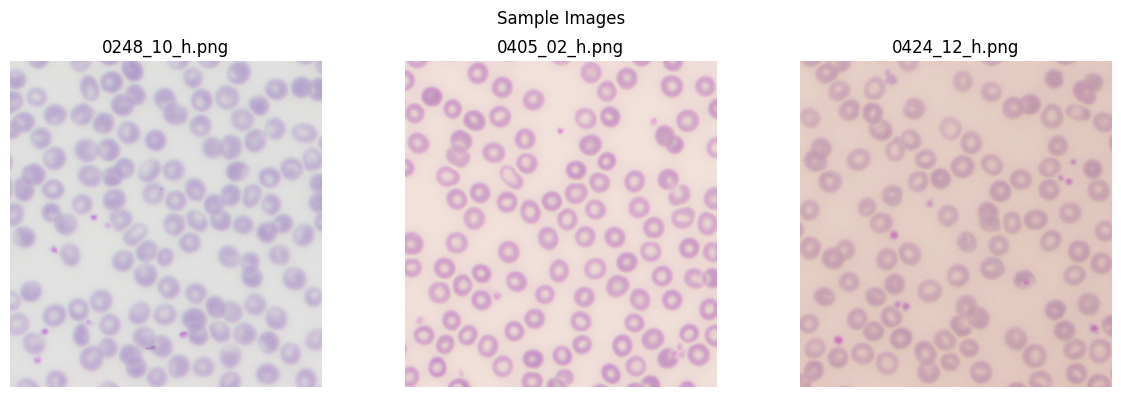

In [4]:
def show_sample(image_paths, title="Sample", cols=3):
    n = min(len(image_paths), cols)
    if n == 0:
        print("No images to show.")
        return
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        img = Image.open(image_paths[i]).convert('RGB')
        ax.imshow(img)
        ax.set_title(Path(image_paths[i]).name[:25])
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

all_images = anerbc_list or chula_list or rbc_list
if all_images:
    show_sample(all_images[:3], "Sample Images")
else:
    print("No images found. Check paths.")

In [5]:
if anerbc_list or chula_list or rbc_list:
    sample_path = (anerbc_list or chula_list or rbc_list)[0]
    img = Image.open(sample_path)
    print(f"Sample: {Path(sample_path).name}")
    print(f"Size: {img.size} (width x height)")
    print(f"Mode: {img.mode}")
else:
    print("No images to check.")

Sample: 0248_10_h.png
Size: (306, 320) (width x height)
Mode: RGB


In [6]:
summary = pd.DataFrame({
    "Dataset": ["AneRBC Healthy", "AneRBC Anemic", "Chula-RBC-12", "RBC"],
    "Count": [anerbc_h_count, anerbc_a_count, chula_count, rbc_count],
    "Path": [str(ANERBC_HEALTHY), str(ANERBC_ANEMIC), str(CHULA_PATH), str(RBC_PATH)]
})
print(summary.to_string(index=False))
print(f"\nTotal images: {anerbc_total + chula_count + rbc_count}")

       Dataset  Count                                                                                                          Path
AneRBC Healthy   6000 C:\Users\nshivane\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Healthy_individuals\Original_Images
 AneRBC Anemic   6000  C:\Users\nshivane\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Anemic_individuals\Original_Images
  Chula-RBC-12    706                                                C:\Users\nshivane\anemia-project\data\raw\Chula-RBC-12\Dataset
           RBC  29338                                                                 C:\Users\nshivane\anemia-project\data\raw\RBC

Total images: 42044


In [7]:
pip install staintools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


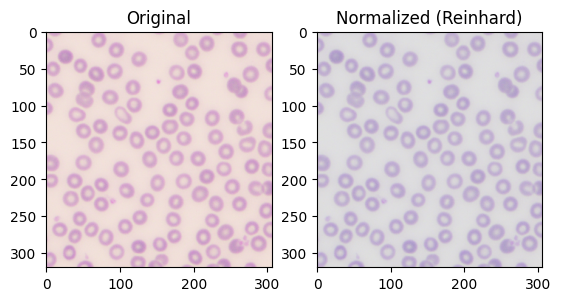

In [8]:
import numpy as np
from PIL import Image
from pathlib import Path

def reinhard_normalize(img_array, reference_path):
    """Reinhard color transfer - no spams dependency."""
    from skimage import exposure
    from skimage.color import rgb2lab, lab2rgb
    
    ref = np.array(Image.open(reference_path).convert('RGB'))
    ref_lab = rgb2lab(ref)
    img_lab = rgb2lab(img_array)
    
    for i in range(3):
        img_lab[:,:,i] = (img_lab[:,:,i] - img_lab[:,:,i].mean()) * (ref_lab[:,:,i].std() / (img_lab[:,:,i].std() + 1e-8)) + ref_lab[:,:,i].mean()
    
    return (lab2rgb(img_lab) * 255).astype(np.uint8)

# Test
ref_path = anerbc_list[0]
img_path = anerbc_list[1]
img = np.array(Image.open(img_path).convert('RGB'))
normalized = reinhard_normalize(img, ref_path)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2)
axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(normalized)
axes[1].set_title("Normalized (Reinhard)")
plt.show()

In [9]:
from pathlib import Path
from sklearn.model_selection import train_test_split

BASE = Path(r"C:\Users\nshivane\anemia-project\data\raw")
ANERBC_H = BASE / "AneRBC" / "AneRBC_dataset" / "AneRBC-II" / "Healthy_individuals" / "Original_Images"
ANERBC_A = BASE / "AneRBC" / "AneRBC_dataset" / "AneRBC-II" / "Anemic_individuals" / "Original_Images"

image_paths = []
labels = []
for p in ANERBC_H.rglob("*.png"):
    image_paths.append(str(p))
    labels.append(0)
for p in ANERBC_A.rglob("*.png"):
    image_paths.append(str(p))
    labels.append(1)

print(f"Total: {len(image_paths)} | Healthy: {labels.count(0)} | Anemic: {labels.count(1)}")

Total: 12000 | Healthy: 6000 | Anemic: 6000


In [10]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

Train: 9600 | Val: 2400


In [11]:
splits_dir = Path(r"C:\Users\nshivane\anemia-project\data\processed\splits")
splits_dir.mkdir(parents=True, exist_ok=True)

for name, paths, lbls in [("train", train_paths, train_labels), ("val", val_paths, val_labels)]:
    with open(splits_dir / f"{name}_paths.txt", "w") as f:
        f.write("\n".join(paths))
    with open(splits_dir / f"{name}_labels.txt", "w") as f:
        f.write("\n".join(map(str, lbls)))
print("Saved to data/processed/splits/")

Saved to data/processed/splits/


In [12]:
import sys
sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from utils.data_loader import PBSDataset, get_transforms
from torch.utils.data import DataLoader

train_dataset = PBSDataset(train_paths, train_labels, transform=get_transforms(train=True))
val_dataset = PBSDataset(val_paths, val_labels, transform=get_transforms(train=False))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

batch_x, batch_y = next(iter(train_loader))
print(f"Batch shape: {batch_x.shape} | Labels: {batch_y.shape}")

Batch shape: torch.Size([32, 3, 224, 224]) | Labels: torch.Size([32])


In [13]:
import torch
import torch.nn as nn
import sys
from pathlib import Path
sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))

from models.cnn_baseline import get_cnn_model
from models.train import train_one_epoch, validate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_cnn_model(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [13:59<00:00,  2.80s/it]


Epoch 1/10 | Train Loss: 0.2997 Acc: 0.8555 | Val Loss: 0.2154 Acc: 0.8988


Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [12:53<00:00,  2.58s/it]


Epoch 2/10 | Train Loss: 0.2026 Acc: 0.9040 | Val Loss: 0.2161 Acc: 0.9012


Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [12:12<00:00,  2.44s/it]


...

Epoch 8/10 | Train Loss: 0.1020 Acc: 0.9530 | Val Loss: 0.1094 Acc: 0.9517


Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [12:43<00:00,  2.54s/it]


Epoch 9/10 | Train Loss: 0.0949 Acc: 0.9563 | Val Loss: 0.1392 Acc: 0.9504


Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [12:50<00:00,  2.57s/it]


Epoch 10/10 | Train Loss: 0.0975 Acc: 0.9574 | Val Loss: 0.1020 Acc: 0.9525


In [14]:
import sys
from pathlib import Path
import numpy as np

sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from features.handcrafted_features import extract_all_features, extract_features_batch

# Test on one image
feat = extract_all_features(train_paths[0])
print(f"Feature vector shape: {feat.shape}")
print(f"Features: morph(6) + texture(4) + color(4) = 14")

# Test on batch (first 10)
feats = extract_features_batch(train_paths[:10])
print(f"Batch shape: {feats.shape}")

Feature vector shape: (14,)
Features: morph(6) + texture(4) + color(4) = 14
Batch shape: (10, 14)


In [15]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from utils.data_loader import get_transforms
from utils.hybrid_dataset import HybridDataset
from features.handcrafted_features import extract_features_batch
from models.hybrid_model import HybridModel

print("Extracting handcrafted features...")
train_hand = extract_features_batch(train_paths)
val_hand = extract_features_batch(val_paths)

scaler = StandardScaler()
train_hand = scaler.fit_transform(train_hand)
val_hand = scaler.transform(val_hand)

train_ds = HybridDataset(train_paths, train_labels, train_hand, transform=get_transforms(train=True))
val_ds = HybridDataset(val_paths, val_labels, val_hand, transform=get_transforms(train=False))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

model = HybridModel(num_classes=2, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()

model.train()
for imgs, hand_feat, labels in train_loader:
    imgs = imgs.to(device)
    hand_feat = hand_feat.to(device)
    labels = labels.to(device)
    logits = model(imgs, hand_feat)
    loss = criterion(logits, labels)
    print(f"Batch loss: {loss.item():.4f}")
    break
print("Forward pass OK!")

Using device: cpu
Extracting handcrafted features...
Batch loss: 0.7117
Forward pass OK!


In [16]:
# Full training loop (10 epochs)
from tqdm import tqdm

num_epochs = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Optional: save best model
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for imgs, hand_feat, labels in tqdm(train_loader, desc="Train"):
        imgs, hand_feat, labels = imgs.to(device), hand_feat.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs, hand_feat)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, hand_feat, labels in val_loader:
            imgs, hand_feat, labels = imgs.to(device), hand_feat.to(device), labels.to(device)
            logits = model(imgs, hand_feat)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    tr_acc = train_correct / train_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} Acc: {tr_acc:.4f} | Val Loss: {val_loss/len(val_loader):.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_hybrid.pt")
        print(f"  -> Saved best model (val_acc={val_acc:.4f})")

Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [15:24<00:00,  3.08s/it]


Epoch 1/10 | Train Loss: 0.3146 Acc: 0.8498 | Val Loss: 0.1854 Acc: 0.9075
  -> Saved best model (val_acc=0.9075)


Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [14:26<00:00,  2.89s/it]


Epoch 2/10 | Train Loss: 0.2238 Acc: 0.8893 | Val Loss: 0.1876 Acc: 0.9108
  -> Saved best model (val_acc=0.9108)


Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [11:15<00:00,  2.25s/it]


...

Epoch 8/10 | Train Loss: 0.1119 Acc: 0.9521 | Val Loss: 0.1074 Acc: 0.9446


Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [12:19<00:00,  2.47s/it]


Epoch 9/10 | Train Loss: 0.1129 Acc: 0.9513 | Val Loss: 0.0972 Acc: 0.9563
  -> Saved best model (val_acc=0.9563)


Train: 100%|█████████████████████████████████████████████████████████████████████████| 300/300 [12:04<00:00,  2.42s/it]


Epoch 10/10 | Train Loss: 0.0974 Acc: 0.9552 | Val Loss: 0.0868 Acc: 0.9617
  -> Saved best model (val_acc=0.9617)


In [17]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns

CLASS_NAMES = ["Healthy", "Anemic"]

def evaluate_model(model, loader, device, is_hybrid=True):
    """Get predictions and labels for a model."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if is_hybrid:
                imgs, hand_feat, labels = batch
                imgs = imgs.to(device)
                hand_feat = hand_feat.to(device)
                logits = model(imgs, hand_feat)
            else:
                imgs, labels = batch
                imgs = imgs.to(device)
                logits = model(imgs)
            labels = labels.to(device)
            preds = logits.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

def print_metrics(y_true, y_pred, model_name):
    """Print precision, recall, F1, confusion matrix."""
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    acc = (y_pred == y_true).mean()
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    print(f"Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    return cm

def plot_confusion_matrix(cm, model_name, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{model_name}\nConfusion Matrix")
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

In [19]:
# Skip CNN - no best_cnn.pt saved during Day 8
# Proceed to Step 3 (Hybrid only)
# Load Hybrid model (use your existing model + load checkpoint)
model.load_state_dict(torch.load("best_hybrid.pt", map_location=device))

# Evaluate Hybrid
y_pred_hybrid, y_true_hybrid = evaluate_model(model, val_loader, device, is_hybrid=True)
cm_hybrid = print_metrics(y_true_hybrid, y_pred_hybrid, "Hybrid Model")


Hybrid Model
Accuracy:  0.9617
Precision: 0.9623
Recall:    0.9617
F1-Score:  0.9617

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.94      0.96      1200
      Anemic       0.95      0.98      0.96      1200

    accuracy                           0.96      2400
   macro avg       0.96      0.96      0.96      2400
weighted avg       0.96      0.96      0.96      2400

Confusion Matrix:
[[1132   68]
 [  24 1176]]


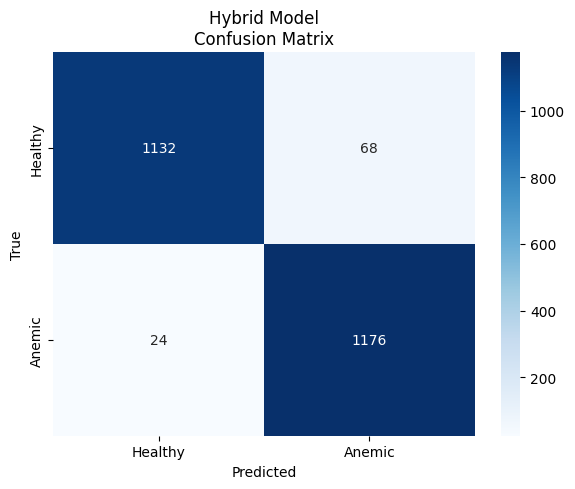

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plot_confusion_matrix(cm_hybrid, "Hybrid Model", ax)
plt.tight_layout()
plt.savefig("confusion_matrix_hybrid.png", dpi=150)
plt.show()

In [21]:
# Summary - Hybrid only
from sklearn.metrics import precision_recall_fscore_support

p_hyb, r_hyb, f_hyb, _ = precision_recall_fscore_support(y_true_hybrid, y_pred_hybrid, average='macro')
acc_hyb = (y_pred_hybrid == y_true_hybrid).mean()

print("\n" + "="*50)
print("HYBRID MODEL - METRICS SUMMARY")
print("="*50)
print(f"Accuracy:   {acc_hyb:.4f}")
print(f"Precision: {p_hyb:.4f}")
print(f"Recall:    {r_hyb:.4f}")
print(f"F1-Score:  {f_hyb:.4f}")
print("="*50)


HYBRID MODEL - METRICS SUMMARY
Accuracy:   0.9617
Precision: 0.9623
Recall:    0.9617
F1-Score:  0.9617


In [22]:
import joblib

# Save scaler (needed for inference on new images)
joblib.dump(scaler, "scaler.pkl")
print("Saved scaler.pkl")

# Optional: create checkpoints folder
from pathlib import Path
Path("checkpoints").mkdir(exist_ok=True)
import shutil
for f in ["best_hybrid.pt", "scaler.pkl"]:
    if Path(f).exists():
        shutil.copy(f, f"checkpoints/{f}")
        print(f"Copied {f} to checkpoints/")

Saved scaler.pkl
Copied best_hybrid.pt to checkpoints/
Copied scaler.pkl to checkpoints/


In [23]:
import importlib
import sys

# Remove cached module so it reloads from disk
if 'utils.grad_cam' in sys.modules:
    del sys.modules['utils.grad_cam']

# Re-import
from utils.grad_cam import GradCAM, overlay_heatmap
print("grad_cam reloaded")

grad_cam reloaded


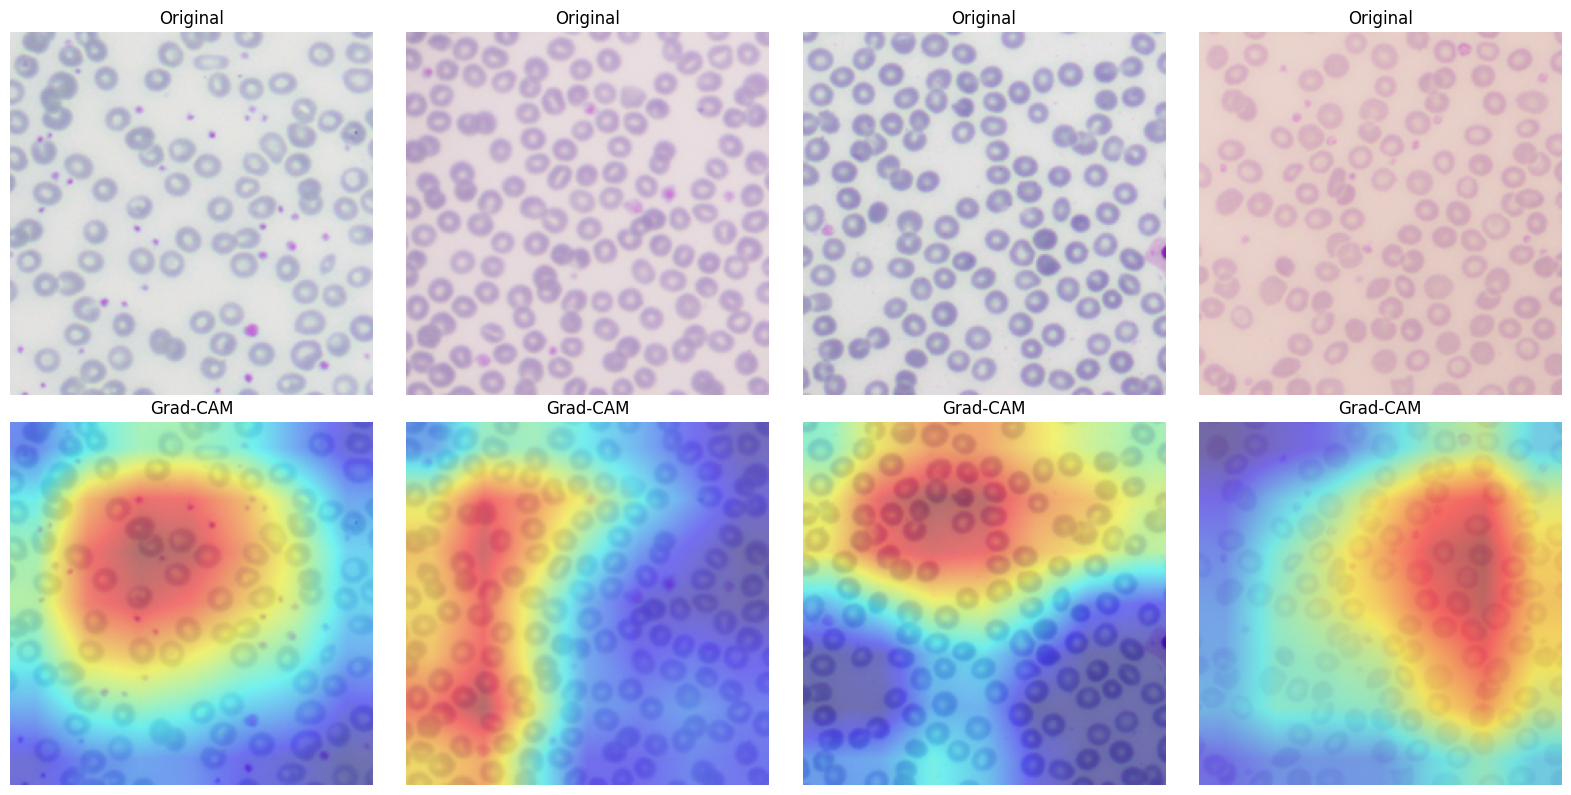

In [24]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from utils.data_loader import get_transforms
from utils.grad_cam import GradCAM, overlay_heatmap
from features.handcrafted_features import extract_all_features

# Load model
model.load_state_dict(torch.load("best_hybrid.pt", map_location=device))
model = model.to(device)

# Target layer: layer4 (last conv), NOT avgpool (features[-1])
target_layer = model.features[-2]
grad_cam = GradCAM(model, target_layer)

# Get samples from val
transform = get_transforms(train=False)
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))

for i in range(n_show):
    idx = i * 100
    img_path = val_paths[idx]
    img_pil = Image.open(img_path).convert("RGB")
    img_np = np.array(img_pil)
    
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    hand_raw = extract_all_features(img_path)
    hand_feat = scaler.transform(hand_raw.reshape(1, -1))
    hand_tensor = torch.tensor(hand_feat, dtype=torch.float32).to(device)
    
    cam = grad_cam.generate(img_tensor, hand_tensor)
    
    img_224 = np.array(Image.fromarray(img_np).resize((224, 224)))
    overlay = overlay_heatmap(img_224, cam)
    
    axes[0, i].imshow(img_224)
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(overlay)
    axes[1, i].set_title("Grad-CAM")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("gradcam_samples.png", dpi=150)
plt.show()

In [25]:
# Test pipeline on a single image from the dataset
import sys
from pathlib import Path
import numpy as np
from PIL import Image

sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from utils.data_loader import get_transforms
from features.handcrafted_features import extract_all_features
from models.hybrid_model import HybridModel

CLASS_NAMES = ["Healthy", "Anemic"]

# Pick an image from validation set (change idx to test different images)
idx = 0
img_path = val_paths[idx]
true_label = val_labels[idx]

# Load and preprocess
img_pil = Image.open(img_path).convert("RGB")
transform = get_transforms(train=False)
img_tensor = transform(img_pil).unsqueeze(0).to(device)

# Handcrafted features
hand_raw = extract_all_features(img_path)
hand_feat = scaler.transform(hand_raw.reshape(1, -1))
hand_tensor = torch.tensor(hand_feat, dtype=torch.float32).to(device)

# Predict
model.eval()
with torch.no_grad():
    logits = model(img_tensor, hand_tensor)
    probs = torch.softmax(logits, dim=1)
    pred = logits.argmax(1).item()
    confidence = probs[0, pred].item()

# Result
print("="*50)
print("PIPELINE TEST")
print("="*50)
print(f"Image: {Path(img_path).name}")
print(f"True label:  {CLASS_NAMES[true_label]} ({true_label})")
print(f"Prediction:  {CLASS_NAMES[pred]} ({pred})")
print(f"Confidence:  {confidence:.4f}")
print(f"Match:       {'✓ CORRECT' if pred == true_label else '✗ WRONG'}")
print("="*50)

PIPELINE TEST
Image: 0051_01_h.png
True label:  Healthy (0)
Prediction:  Healthy (0)
Confidence:  1.0000
Match:       ✓ CORRECT


In [26]:
# Test pipeline with interpretability - user enters image path
import sys
from pathlib import Path
import numpy as np
from PIL import Image

sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from utils.data_loader import get_transforms
from features.handcrafted_features import extract_all_features
from models.hybrid_model import HybridModel

CLASS_NAMES = ["Healthy", "Anemic"]

# Handcrafted feature names (14 total)
FEATURE_NAMES = [
    "area", "perimeter", "circularity", "eccentricity", "solidity", "extent",
    "contrast", "correlation", "energy", "homogeneity",
    "mean_R", "mean_G", "mean_B", "pallor_ratio"
]

# User enters path
input_image_path = input("Enter image path: ").strip().strip('"').strip("'")

# Load and preprocess
img_pil = Image.open(input_image_path).convert("RGB")
transform = get_transforms(train=False)
img_tensor = transform(img_pil).unsqueeze(0).to(device)

# Handcrafted features
hand_raw = extract_all_features(input_image_path)
hand_feat = scaler.transform(hand_raw.reshape(1, -1))
hand_tensor = torch.tensor(hand_feat, dtype=torch.float32).to(device)

# Forward + get attention weights
model.eval()
with torch.no_grad():
    cnn_feat = model.features(img_tensor)
    cnn_flat = cnn_feat.flatten(1)
    combined = torch.cat([cnn_flat, hand_tensor], dim=1)
    attn = model.fusion.attention(combined)
    attn_cnn = attn[0, 0].item()
    attn_hand = attn[0, 1].item()
    
    logits = model(img_tensor, hand_tensor)
    probs = torch.softmax(logits, dim=1)
    pred = logits.argmax(1).item()
    confidence = probs[0, pred].item()

# Result
print("="*60)
print("PIPELINE TEST - YOUR IMAGE (with interpretability)")
print("="*60)
print(f"Image: {Path(input_image_path).name}")
print(f"\nPrediction:  {CLASS_NAMES[pred]} ({pred})")
print(f"Confidence:  {confidence:.4f} ({confidence*100:.2f}%)")
print("\n" + "-"*60)
print("ATTENTION WEIGHTS (what the model relied on)")
print("-"*60)
print(f"  CNN features:        {attn_cnn:.2%}")
print(f"  Handcrafted features: {attn_hand:.2%}")
print("\n" + "-"*60)
print("HANDCRAFTED FEATURES (morphology, texture, color)")
print("-"*60)
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {name:<18} {hand_raw[i]:>10.4f}")
print("="*60)

Enter image path:  "C:\Users\nshivane\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Healthy_individuals\Original_images\0002_11_h.png"


PIPELINE TEST - YOUR IMAGE (with interpretability)
Image: 0002_11_h.png

Prediction:  Healthy (0)
Confidence:  0.9807 (98.07%)

------------------------------------------------------------
ATTENTION WEIGHTS (what the model relied on)
------------------------------------------------------------
  CNN features:        88.38%
  Handcrafted features: 11.62%

------------------------------------------------------------
HANDCRAFTED FEATURES (morphology, texture, color)
------------------------------------------------------------
  area               36831.0000
  perimeter           9751.1890
  circularity            0.0049
  eccentricity           0.3126
  solidity               0.3764
  extent                 0.3761
  contrast              43.4052
  correlation            0.9661
  energy                 0.0372
  homogeneity            0.2460
  mean_R               195.9385
  mean_G               182.4641
  mean_B               208.6242
  pallor_ratio           0.4069


Enter image path:  "C:\Users\nshivane\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Anemic_individuals\Original_images\0011_03_a.png"


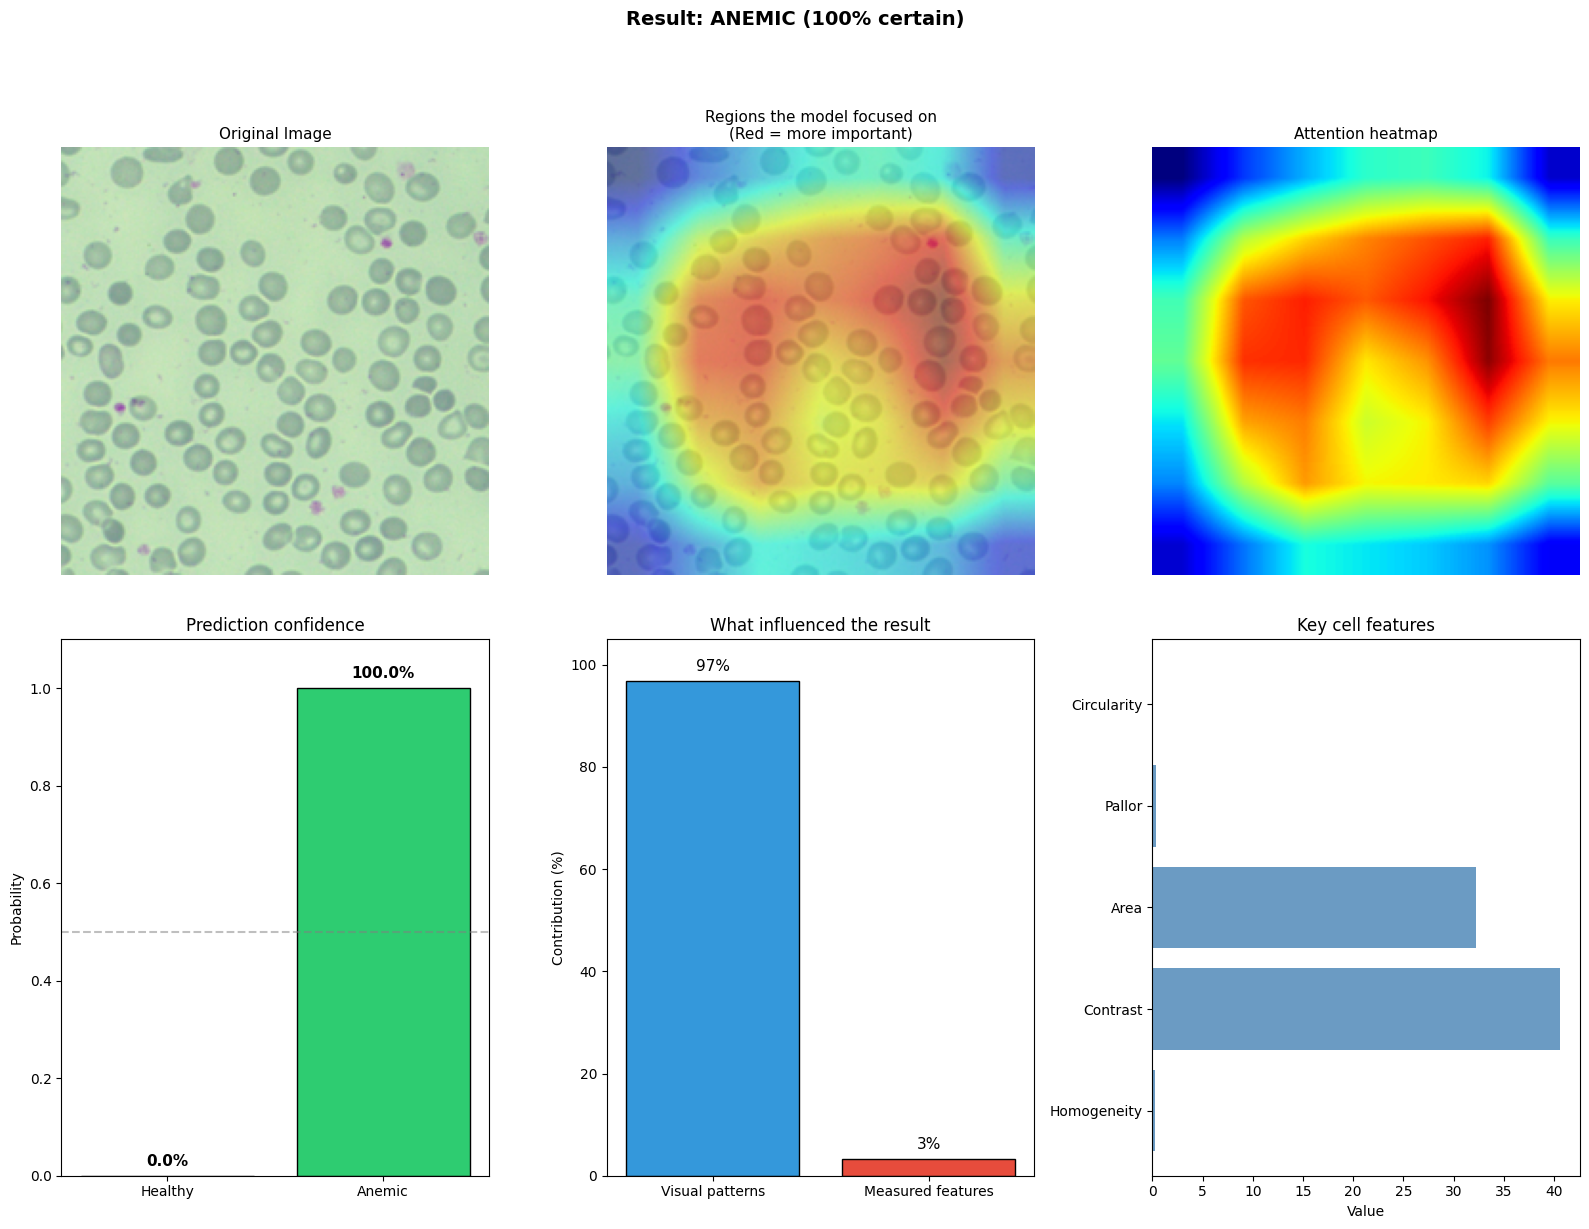


  BLOOD SMEAR ANALYSIS RESULT

  Image analysed: 0011_03_a.png

  Result: ANEMIC
  Certainty: 100%

------------------------------------------------------------
  What influenced this result
------------------------------------------------------------

  • Visual pattern analysis: 97%
  • Measured cell features:  3%

  Cell features observed:
    - Shape (roundness):     More irregular
    - Central pallor:        More noticeable
    - Cell size:             Normal

  Note: This is a screening aid. Please consult a doctor
  for diagnosis and treatment.

  TECHNICAL DETAILS
Image: 0011_03_a.png
Prediction:  Anemic (1)
Confidence:  0.9999 (99.99%)

------------------------------------------------------------
ATTENTION WEIGHTS
------------------------------------------------------------
  CNN features:         96.82%
  Handcrafted features: 3.18%

------------------------------------------------------------
HANDCRAFTED FEATURES
------------------------------------------------------------

In [28]:
# Test pipeline - with image, Grad-CAM, and enhanced graphs
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from utils.data_loader import get_transforms
from utils.grad_cam import GradCAM, overlay_heatmap
from features.handcrafted_features import extract_all_features
from models.hybrid_model import HybridModel

CLASS_NAMES = ["Healthy", "Anemic"]
FEATURE_NAMES = [
    "area", "perimeter", "circularity", "eccentricity", "solidity", "extent",
    "contrast", "correlation", "energy", "homogeneity",
    "mean_R", "mean_G", "mean_B", "pallor_ratio"
]

# User enters path
input_image_path = input("Enter image path: ").strip().strip('"').strip("'")

# Load and preprocess
img_pil = Image.open(input_image_path).convert("RGB")
img_np = np.array(img_pil)
transform = get_transforms(train=False)
img_tensor = transform(img_pil).unsqueeze(0).to(device)

# Handcrafted features
hand_raw = extract_all_features(input_image_path)
hand_feat = scaler.transform(hand_raw.reshape(1, -1))
hand_tensor = torch.tensor(hand_feat, dtype=torch.float32).to(device)

# Grad-CAM
target_layer = model.features[-2]
grad_cam = GradCAM(model, target_layer)
cam = grad_cam.generate(img_tensor, hand_tensor)

# Resize original for overlay
img_224 = np.array(Image.fromarray(img_np).resize((224, 224)))
overlay = overlay_heatmap(img_224, cam)

# Predict
model.eval()
with torch.no_grad():
    cnn_feat = model.features(img_tensor)
    cnn_flat = cnn_feat.flatten(1)
    combined = torch.cat([cnn_flat, hand_tensor], dim=1)
    attn = model.fusion.attention(combined)
    attn_cnn = attn[0, 0].item()
    attn_hand = attn[0, 1].item()
    
    logits = model(img_tensor, hand_tensor)
    probs = torch.softmax(logits, dim=1)
    pred = logits.argmax(1).item()
    confidence = probs[0, pred].item()

result = "ANEMIC" if pred == 1 else "HEALTHY"
certainty = int(round(confidence * 100))

# ========== ENHANCED PLOTS ==========
fig = plt.figure(figsize=(16, 12))

# Row 1: Images
ax1 = fig.add_subplot(2, 3, 1)
ax1.imshow(img_224)
ax1.set_title("Original Image", fontsize=11)
ax1.axis("off")

ax2 = fig.add_subplot(2, 3, 2)
ax2.imshow(overlay)
ax2.set_title("Regions the model focused on\n(Red = more important)", fontsize=11)
ax2.axis("off")

ax3 = fig.add_subplot(2, 3, 3)
ax3.imshow(cam, cmap='jet')
ax3.set_title("Attention heatmap", fontsize=11)
ax3.axis("off")

# Row 2: Charts
# 1. Prediction probabilities
ax4 = fig.add_subplot(2, 3, 4)
probs_np = probs.cpu().numpy()[0]
colors = ['#2ecc71' if i == pred else '#bdc3c7' for i in range(2)]
bars = ax4.bar(CLASS_NAMES, probs_np, color=colors, edgecolor='black')
ax4.set_ylabel("Probability")
ax4.set_title("Prediction confidence")
ax4.set_ylim(0, 1.1)
for bar, p in zip(bars, probs_np):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{p:.1%}', ha='center', fontsize=11, fontweight='bold')
ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# 2. Attention weights
ax5 = fig.add_subplot(2, 3, 5)
attn_vals = [attn_cnn * 100, attn_hand * 100]
attn_labels = ['Visual patterns', 'Measured features']
colors_attn = ['#3498db', '#e74c3c']
bars2 = ax5.bar(attn_labels, attn_vals, color=colors_attn, edgecolor='black')
ax5.set_ylabel("Contribution (%)")
ax5.set_title("What influenced the result")
ax5.set_ylim(0, 105)
for bar, v in zip(bars2, attn_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{v:.0f}%', ha='center', fontsize=11)

# 3. Key handcrafted features (bar chart)
ax6 = fig.add_subplot(2, 3, 6)
key_names = ['Circularity', 'Pallor', 'Area', 'Contrast', 'Homogeneity']
key_vals = [hand_raw[2], hand_raw[13], hand_raw[0]/1000, hand_raw[6], hand_raw[9]]
ax6.barh(key_names, key_vals, color='steelblue', alpha=0.8)
ax6.set_xlabel("Value")
ax6.set_title("Key cell features")
ax6.invert_yaxis()

plt.suptitle(f"Result: {result} ({certainty}% certain)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== NON-TECHNICAL OUTPUT ==========
print()
print("="*60)
print("  BLOOD SMEAR ANALYSIS RESULT")
print("="*60)
print()
print(f"  Image analysed: {Path(input_image_path).name}")
print()
print(f"  Result: {result}")
print(f"  Certainty: {certainty}%")
print()
print("-"*60)
print("  What influenced this result")
print("-"*60)
print()
print(f"  • Visual pattern analysis: {attn_cnn*100:.0f}%")
print(f"  • Measured cell features:  {attn_hand*100:.0f}%")
print()
print("  Cell features observed:")
print(f"    - Shape (roundness):     {'More irregular' if hand_raw[2] < 0.85 else 'More round'}")
print(f"    - Central pallor:        {'More noticeable' if hand_raw[13] > 0.15 else 'Less noticeable'}")
print(f"    - Cell size:             {'Smaller' if hand_raw[0] < 1000 else 'Normal'}")
print()
print("="*60)
print("  Note: This is a screening aid. Please consult a doctor")
print("  for diagnosis and treatment.")
print("="*60)

# ========== TECHNICAL OUTPUT ==========
print()
print("="*60)
print("  TECHNICAL DETAILS")
print("="*60)
print(f"Image: {Path(input_image_path).name}")
print(f"Prediction:  {CLASS_NAMES[pred]} ({pred})")
print(f"Confidence:  {confidence:.4f} ({confidence*100:.2f}%)")
print()
print("-"*60)
print("ATTENTION WEIGHTS")
print("-"*60)
print(f"  CNN features:         {attn_cnn:.2%}")
print(f"  Handcrafted features: {attn_hand:.2%}")
print()
print("-"*60)
print("HANDCRAFTED FEATURES")
print("-"*60)
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {name:<18} {hand_raw[i]:>10.4f}")
print("="*60)